In [54]:
from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,cross_val_score
import numpy as np
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [55]:
x, y = make_moons(
    n_samples=500,
    noise=0.4,
    random_state=42
)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

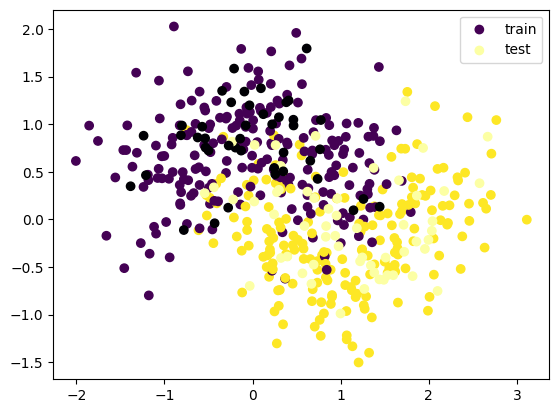

In [56]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_train,cmap='viridis',label='train')
plt.scatter(x_test[:,0],x_test[:,1],c=y_test,cmap='inferno',label='test')
plt.legend()

CV score for DecisionTreeClassifier(random_state=42) is 0.8225736755682309
Accuracy on test set is 0.82
CV score for KNeighborsClassifier() is 0.8301356840376803
Accuracy on test set is 0.81


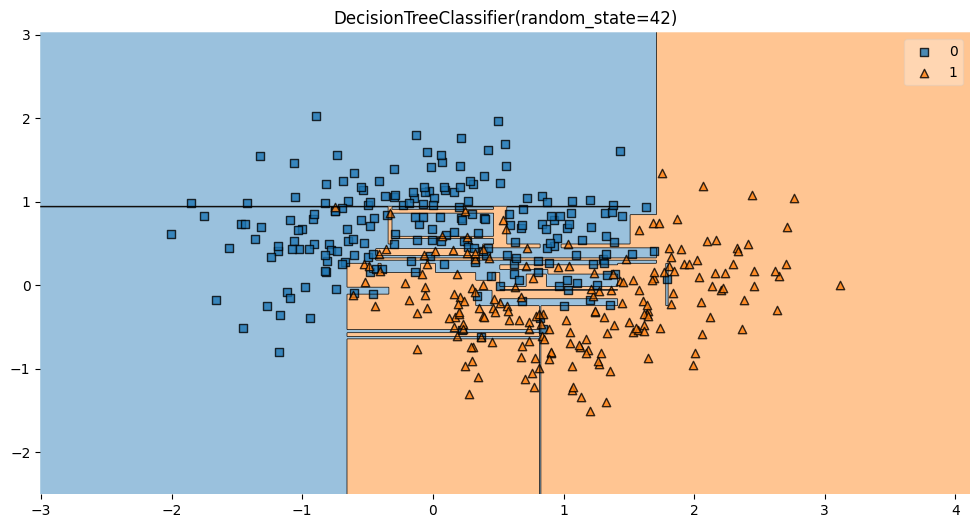

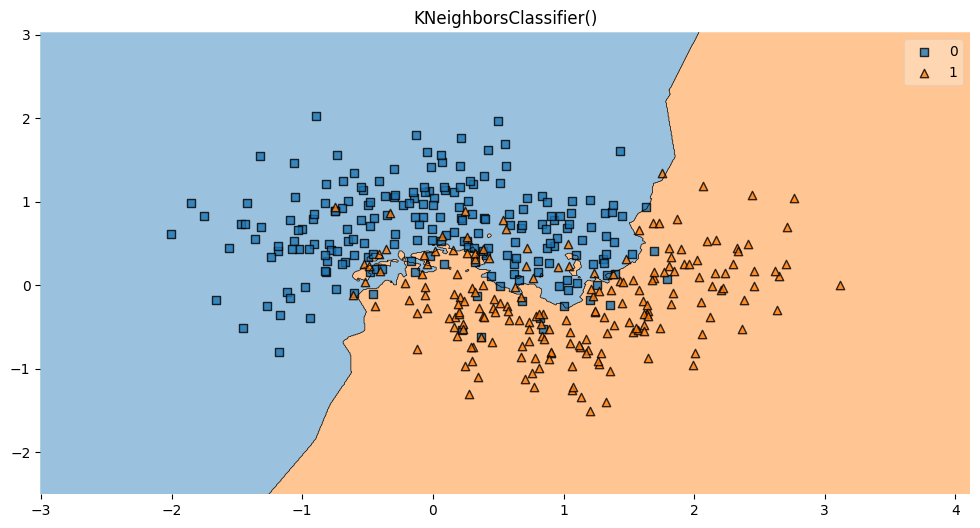

In [57]:
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()
classifiers = [dt,knn]
for clf in classifiers:
    clf.fit(x_train,y_train)
    cv = cross_val_score(clf,x_train,y_train,scoring='accuracy',cv=7)
    print(f"CV score for {clf} is {np.mean(cv)}")
    y_pred = clf.predict(x_test)
    print(f"Accuracy on test set is {accuracy_score(y_test,y_pred)}")
    plt.figure(figsize=(12,6))
    plot_decision_regions(x_train,y_train,clf)
    plt.title(clf)

# Bagging


cv score for decision tree is 0.8400743237403854 for sample 0.2
Accuracy of dt is 0.83 for sample 0.2
cv score for decision tree is 0.8525192291072509 for sample 0.25
Accuracy of dt is 0.84 for sample 0.25
cv score for decision tree is 0.8425373779275774 for sample 0.3
Accuracy of dt is 0.81 for sample 0.3
cv score for decision tree is 0.8400743237403853 for sample 0.35
Accuracy of dt is 0.82 for sample 0.35
cv score for decision tree is 0.8500129634430903 for sample 0.4
Accuracy of dt is 0.82 for sample 0.4
cv score for decision tree is 0.8450436435917379 for sample 0.45
Accuracy of dt is 0.82 for sample 0.45
cv score for decision tree is 0.8550254947714112 for sample 0.5
Accuracy of dt is 0.82 for sample 0.5
cv score for decision tree is 0.8550254947714112 for sample 0.55
Accuracy of dt is 0.82 for sample 0.55
cv score for decision tree is 0.8450004321147696 for sample 0.6
Accuracy of dt is 0.82 for sample 0.6


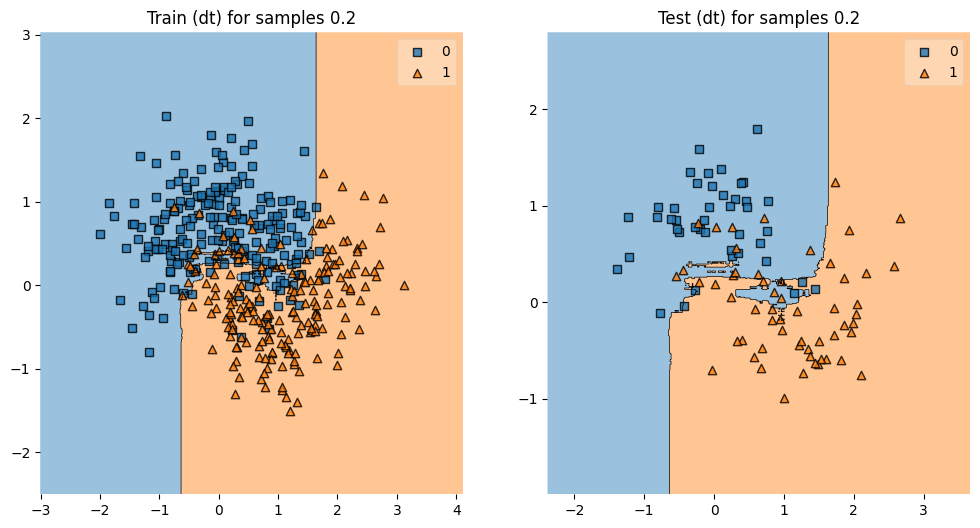

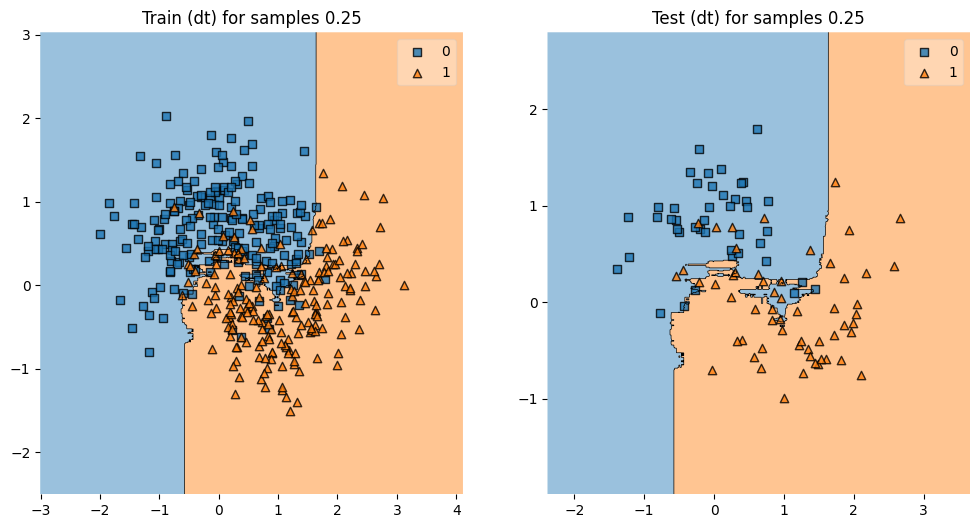

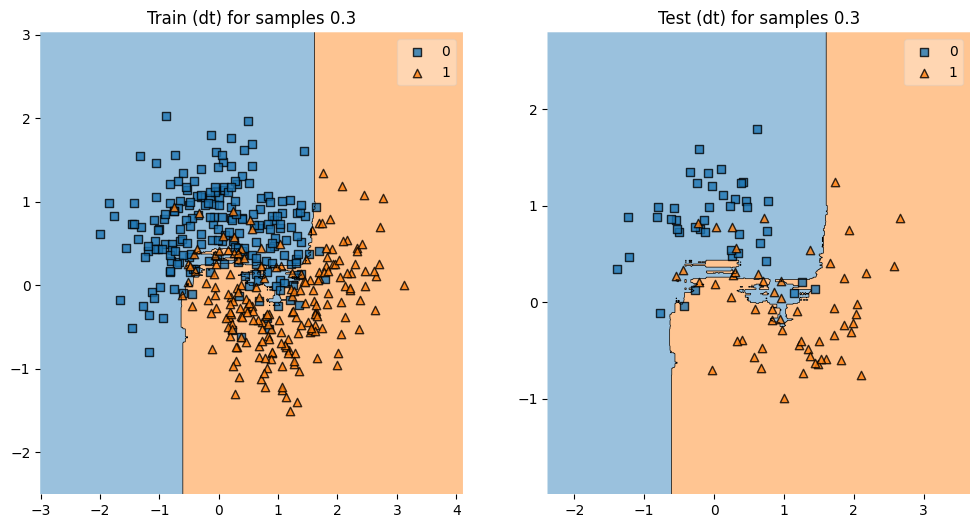

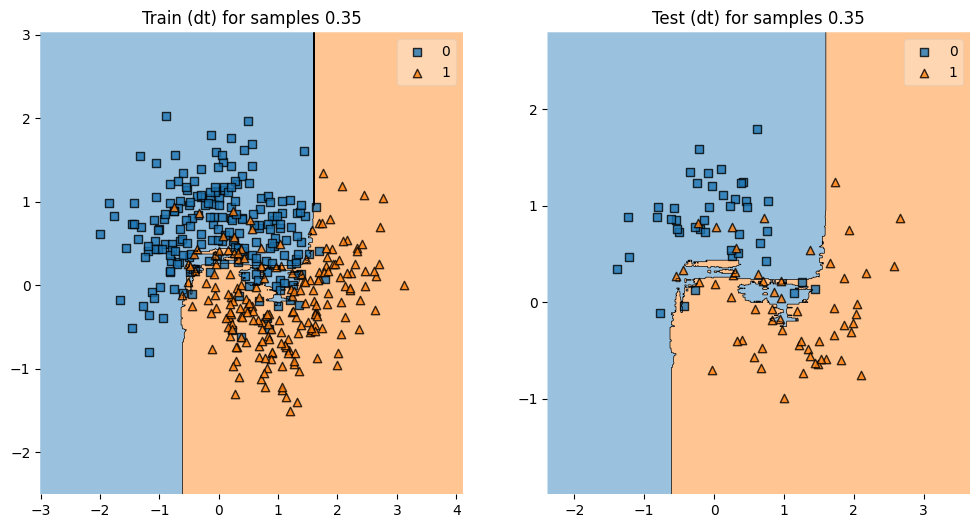

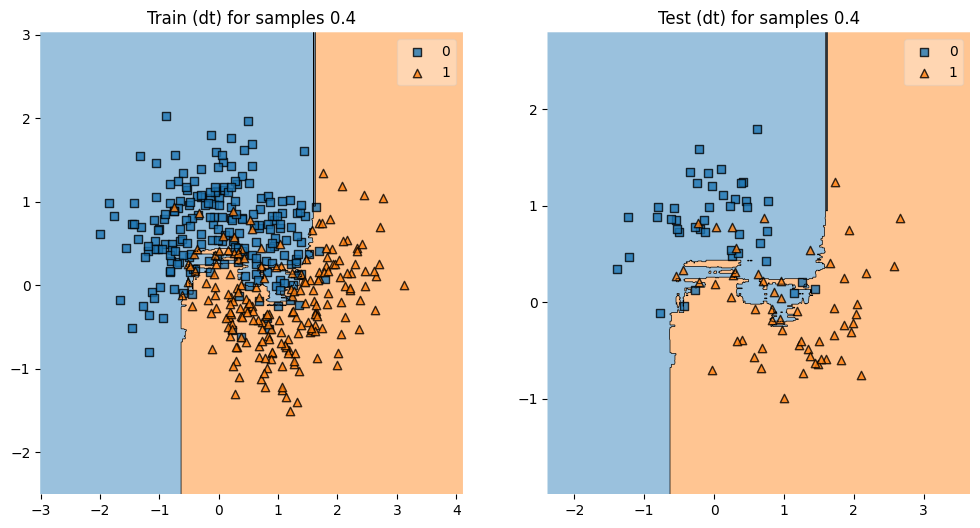

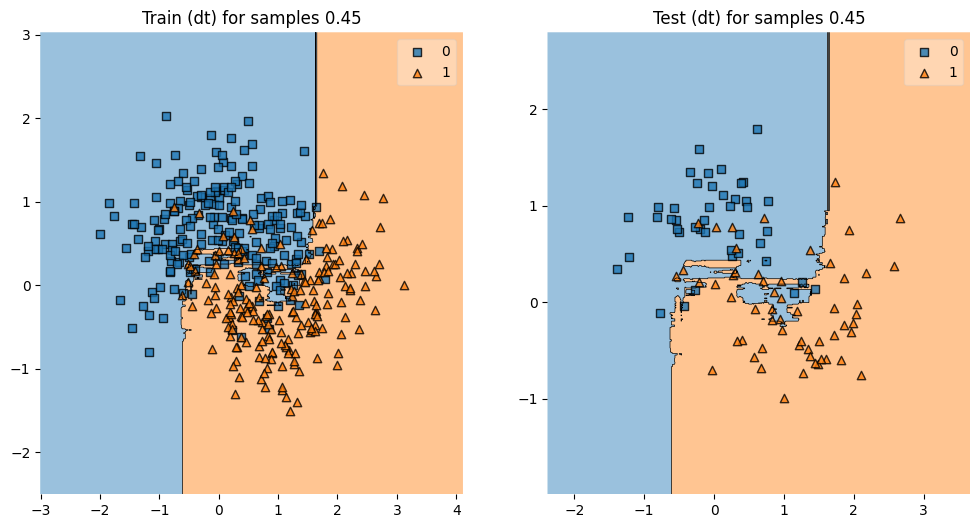

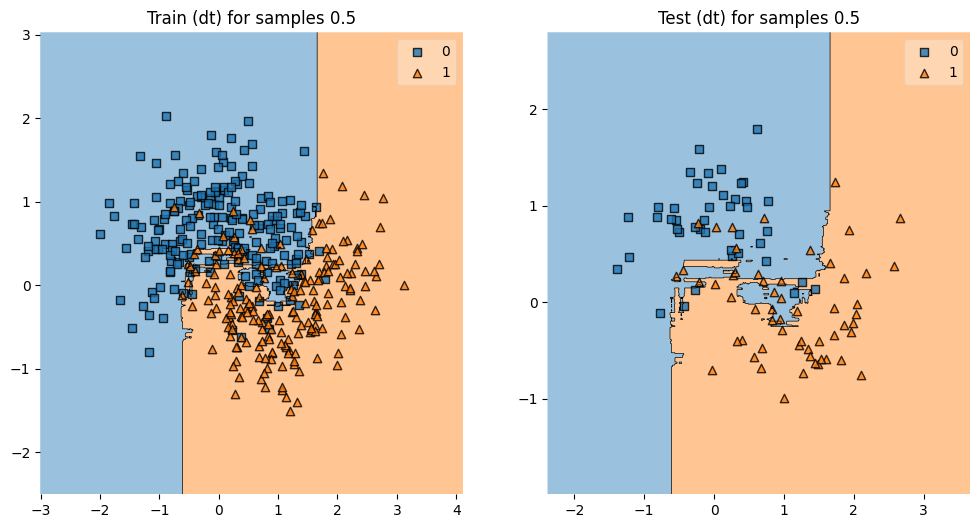

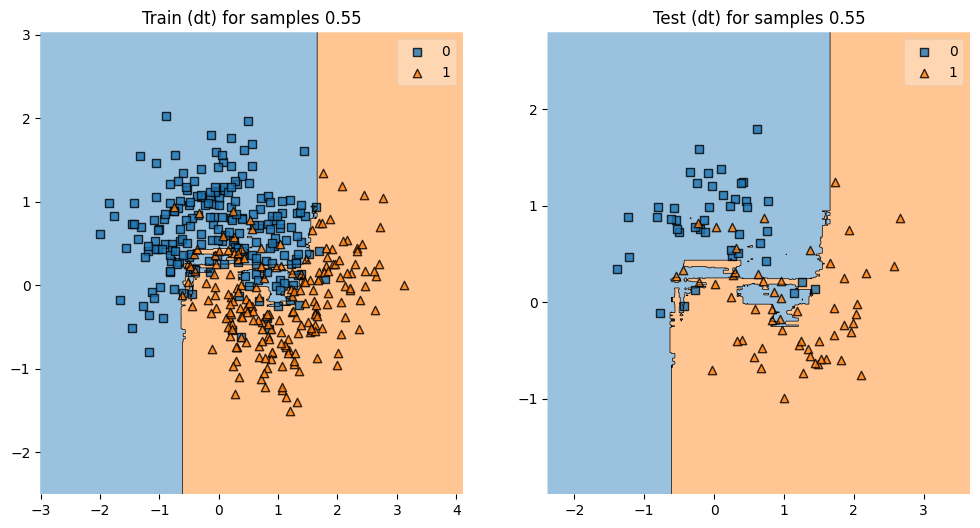

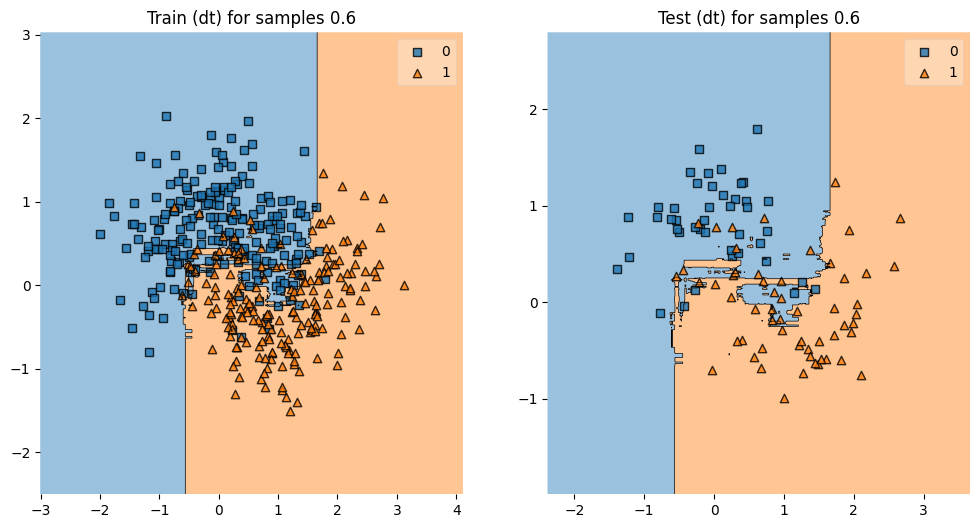

In [58]:
samples = [0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6]
for sample in samples:
    bag_dt = BaggingClassifier(estimator= DecisionTreeClassifier(),n_estimators=100,max_samples=sample,bootstrap=True,random_state=42)
    bag_dt.fit(x_train,y_train)
    cv_dt = cross_val_score(bag_dt,x_train,y_train,cv=7,scoring='accuracy')
    print(f"cv score for decision tree is {np.mean(cv_dt)} for sample {sample}")
    y_pred_dt = bag_dt.predict(x_test)
    print(f"Accuracy of dt is {accuracy_score(y_test,y_pred_dt)} for sample {sample}")
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    plot_decision_regions(x_train,y_train,bag_dt)
    plt.title(f"Train (dt) for samples {sample}")
    plt.subplot(122)
    plot_decision_regions(x_test,y_test,bag_dt)
    plt.title(f"Test (dt) for samples {sample}")



cv score for knn is 0.85757497191254
Accuracy of knn is 0.79


Text(0.5, 1.0, 'Test (knn)')

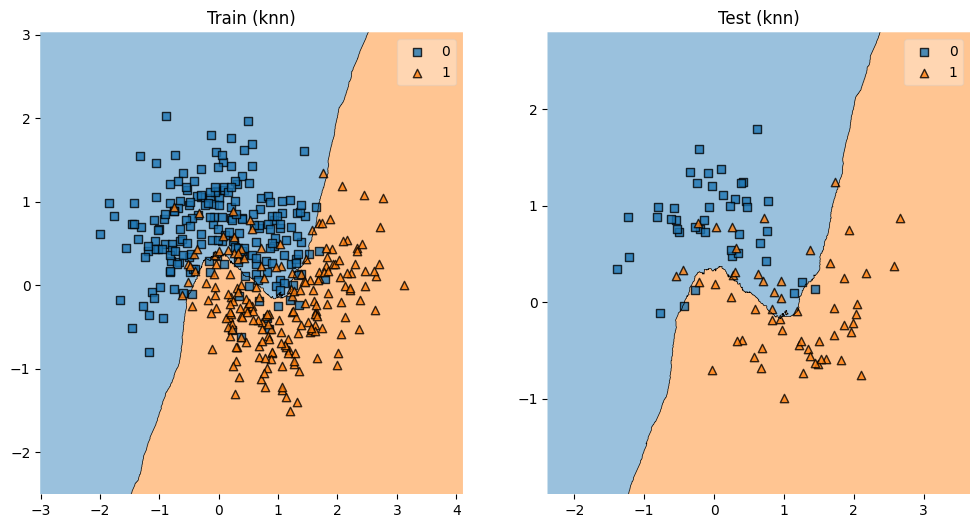

In [59]:
bag_knn = BaggingClassifier(estimator=KNeighborsClassifier(),n_estimators=100,max_samples=0.3,bootstrap=True,random_state=42)
bag_knn.fit(x_train,y_train)
cv_knn = cross_val_score(bag_knn,x_train,y_train,cv=7,scoring='accuracy')
print(f"cv score for knn is {np.mean(cv_knn)}")
y_pred_knn = bag_knn.predict(x_test)
print(f"Accuracy of knn is {accuracy_score(y_test,y_pred_knn)}")
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_decision_regions(x_train,y_train,bag_knn)
plt.title("Train (knn)")
plt.subplot(122)
plot_decision_regions(x_test,y_test,bag_knn)
plt.title("Test (knn)")

# Pasting

cv score for decision tree is 0.8475931207328665
Accuracy of dt is 0.84


Text(0.5, 1.0, 'Test (dt)')

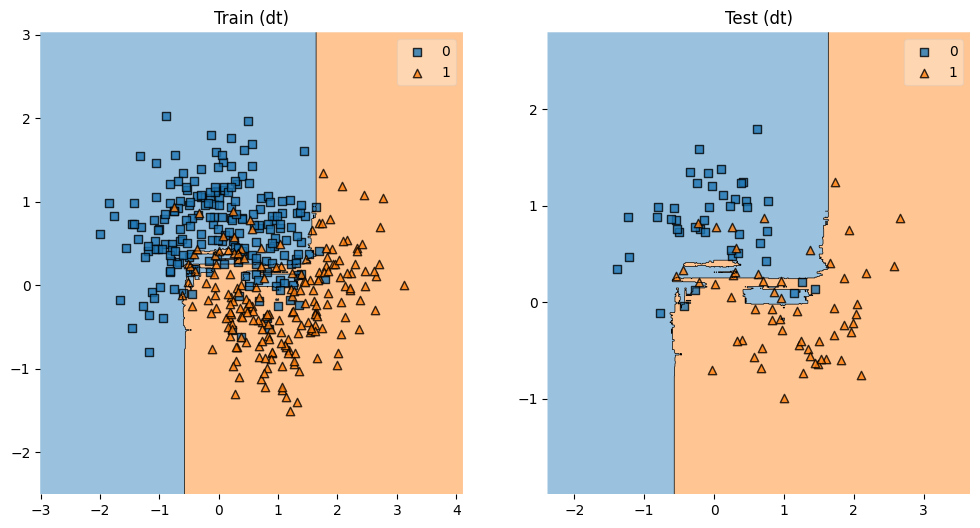

In [60]:
bag_dt = BaggingClassifier(estimator= DecisionTreeClassifier(),n_estimators=100,max_samples=0.3,bootstrap=False,random_state=42)

bag_dt.fit(x_train,y_train)
cv_dt = cross_val_score(bag_dt,x_train,y_train,cv=7,scoring='accuracy')
print(f"cv score for decision tree is {np.mean(cv_dt)}")
y_pred_dt = bag_dt.predict(x_test)
print(f"Accuracy of dt is {accuracy_score(y_test,y_pred_dt)}")
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_decision_regions(x_train,y_train,bag_dt)
plt.title("Train (dt)")
plt.subplot(122)
plot_decision_regions(x_test,y_test,bag_dt)
plt.title("Test (dt)")

# Random subspaces

cv score for decision tree is 0.742675654653876
Accuracy of dt is 0.72


Text(0.5, 1.0, 'Test (dt)')

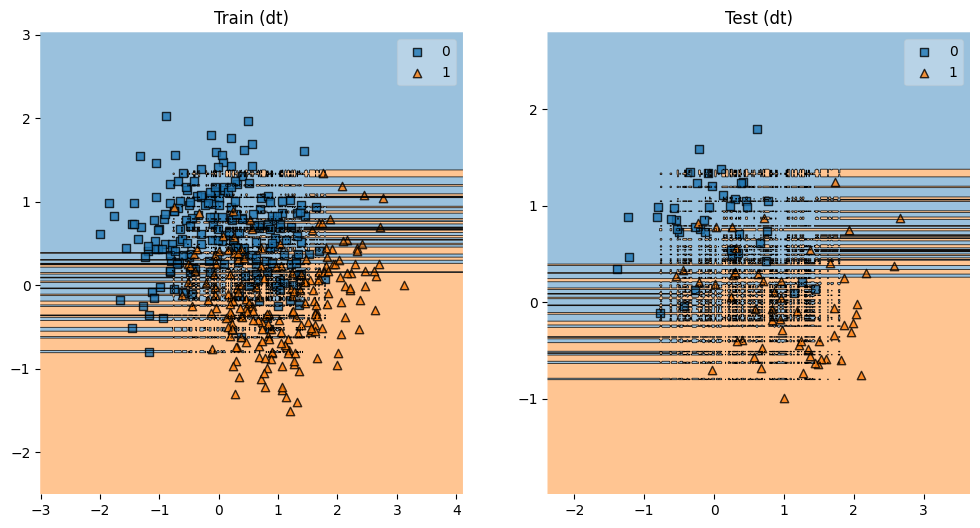

In [63]:
bag_dt = BaggingClassifier(estimator= DecisionTreeClassifier(),n_estimators=100,max_features=0.5,random_state=42)

bag_dt.fit(x_train,y_train)
cv_dt = cross_val_score(bag_dt,x_train,y_train,cv=7,scoring='accuracy')
print(f"cv score for decision tree is {np.mean(cv_dt)}")
y_pred_dt = bag_dt.predict(x_test)
print(f"Accuracy of dt is {accuracy_score(y_test,y_pred_dt)}")
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_decision_regions(x_train,y_train,bag_dt)
plt.title("Train (dt)")
plt.subplot(122)
plot_decision_regions(x_test,y_test,bag_dt)
plt.title("Test (dt)")

cv score for decision tree is 0.8025235502549476
Accuracy of dt is 0.77


Text(0.5, 1.0, 'Test (dt)')

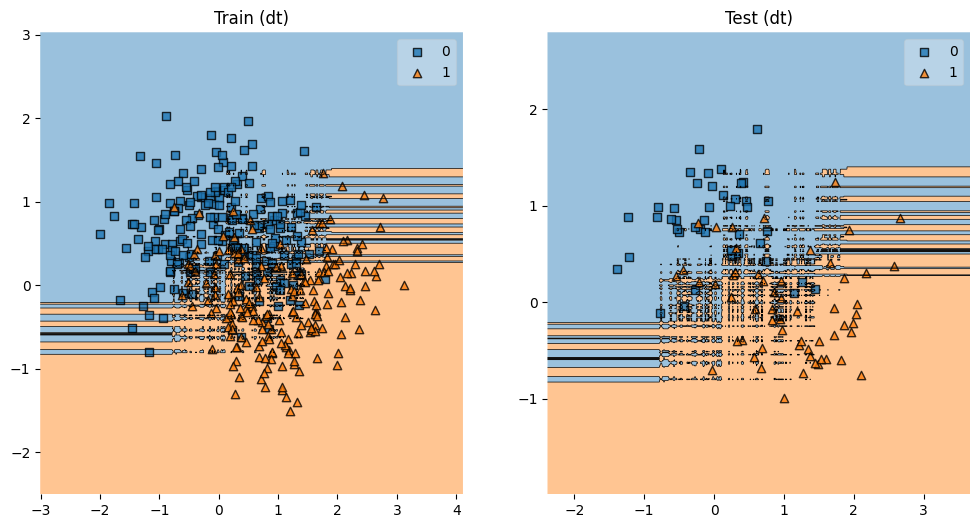

In [62]:
bag_dt = BaggingClassifier(estimator= DecisionTreeClassifier(),n_estimators=100,max_features=0.2,max_samples=0.3,bootstrap=False,random_state=42)

bag_dt.fit(x_train,y_train)
cv_dt = cross_val_score(bag_dt,x_train,y_train,cv=7,scoring='accuracy')
print(f"cv score for decision tree is {np.mean(cv_dt)}")
y_pred_dt = bag_dt.predict(x_test)
print(f"Accuracy of dt is {accuracy_score(y_test,y_pred_dt)}")
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_decision_regions(x_train,y_train,bag_dt)
plt.title("Train (dt)")
plt.subplot(122)
plot_decision_regions(x_test,y_test,bag_dt)
plt.title("Test (dt)")